## GS - Generative AI for Engineering
### Tema: Economia Espacial - Predição de Risco de Colisão Orbital

---
#### Problema Escolhido

A órbita baixa da Terra (LEO, 160-2000 km) concentra mais de **27.000 objetos rastreados** entre satélites ativos e debris. O risco de colisões em cascata, conhecido como **Síndrome de Kessler**, pode inutilizar faixas inteiras de órbita e comprometer telecomunicações, GPS e observação da Terra.


A NASA mantém um sistema chamado **CARA (Conjunction Assessment Risk Analysis)** que monitora aproximações perigosas (conjunções) e decide quando uma manobra evasiva é necessária. Nesse trabalho, desenvolvemos um pipeline completo de ML para:

- **Classificar** o nível de risco de uma conjunção orbital (Baixo/Médio/Alto/Crítico)
- **Regredir** a probabilidade de colisão como valor contínuo
- **Interpretar** quais variáveis mais influenciam as predições (SHAP)

---

### Etapa 1 - Obtenção dos Dados

Foi utilizada **IA generativa (Claude)** para criar um conjunto de dados sintético com **1.400 conjunções orbitais** e **24 variáveis**, seguindo distribuições baseadas em parâmetros reais do Space-Track.org e do formato NASA CARA.

A variável alvo de probabilidade de colisão (`pc_foster`) foi calculada com uma versão simplificada do **Método Foster**, que é o padrão da NASA para esse cálculo.

### Variáveis do Dataset

| Variável | Tipo | Descrição |
|---|---|---|
| `altitude_km` | Numérica | Altitude orbital do objeto primário |
| `inclinacao_graus` | Numérica | Inclinação orbital |
| `excentricidade` | Numérica | Excentricidade da órbita |
| `distancia_miss_km` | Numérica | Distância mínima de aproximação |
| `velocidade_relativa_kms` | Numérica | Velocidade relativa no ponto mais próximo |
| `rcs_objeto1_m2` / `rcs_objeto2_m2` | Numérica | Seção transversal de radar (tamanho do objeto) |
| `cov_radial` / `cov_transversal` / `cov_normal` | Numérica | Covariâncias de posição (incerteza orbital) |
| `tempo_tca_horas` | Numérica | Horas até o ponto de máxima aproximação |
| `obj1_ativo` / `obj2_debris` | Binária | Características dos objetos |
| `indice_solar_f107` | Numérica | Atividade solar (afeta arrasto atmosférico em LEO) |
| `pc_foster` | Numérica | **Target (regressão):** probabilidade de colisão |
| `nivel_risco` | Categórica | **Target (classificação):** 0=Baixo, 1=Médio, 2=Alto, 3=Crítico |

In [23]:
# Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, mean_squared_error, r2_score, mean_absolute_percentage_error
)
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier
import shap
import joblib
import os

np.random.seed(42)
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [24]:
# ============================================================
# Geração do dataset sintético
# 1.200 amostras x 16 variáveis base (+ 8 após feature engineering)
# ============================================================
N = 1400

# Parâmetros orbitais
altitude_km       = np.random.uniform(200, 2000, N)
inclinacao_graus  = np.random.uniform(0, 98, N)
excentricidade    = np.random.beta(1.2, 12, N) * 0.3

# Parâmetros da conjunção (aproximação entre objetos)
distancia_miss    = np.clip(np.random.exponential(2.0, N) + 0.01, 0.001, 25)
velocidade_rel    = np.clip(np.random.normal(10, 3, N), 0.5, 16)
rcs_obj1          = np.random.lognormal(0.5, 1.5, N)
rcs_obj2          = np.random.lognormal(-0.5, 1.8, N)

# Incerteza posicional (covariâncias)
cov_radial        = np.random.exponential(500, N)
cov_transversal   = np.random.exponential(2000, N)
cov_normal_v      = np.random.exponential(300, N)

# Tempo até o ponto de máxima aproximação
tempo_tca         = np.random.uniform(0.5, 72, N)

# Flags dos objetos
obj1_ativo        = np.random.binomial(1, 0.55, N)
obj2_debris       = np.random.binomial(1, 0.70, N)

# Índice de atividade solar
solar_f107        = np.clip(np.random.normal(130, 40, N), 65, 240)

# Probabilidade de colisão - método Foster simplificado
rcs_comb = rcs_obj1 + rcs_obj2
cov_comb = np.sqrt(cov_radial**2 + cov_normal_v**2)

log_pc = (
    -4.5
    - 3.2 * np.log1p(distancia_miss)
    + 0.8 * np.log1p(rcs_comb)
    + 0.6 * np.log1p(cov_comb / 1000)
    + 0.3 * np.log1p(velocidade_rel)
    - 0.02 * tempo_tca
    + np.random.normal(0, 0.4, N)
)
pc_foster = np.clip(1 / (1 + np.exp(-log_pc)), 1e-8, 0.9999)

# Classificação de risco seguindo padrão NASA CARA
# Pc < 1e-5 = Baixo | 1e-5 a 1e-4 = Médio | 1e-4 a 1e-3 = Alto | > 1e-3 = Crítico
nivel_risco = pd.cut(
    pc_foster,
    bins=[-np.inf, 1e-5, 1e-4, 1e-3, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

# Montagem do DataFrame
df = pd.DataFrame({
    'altitude_km':             altitude_km,
    'inclinacao_graus':        inclinacao_graus,
    'excentricidade':          excentricidade,
    'distancia_miss_km':       distancia_miss,
    'velocidade_relativa_kms': velocidade_rel,
    'rcs_objeto1_m2':          rcs_obj1,
    'rcs_objeto2_m2':          rcs_obj2,
    'cov_radial':              cov_radial,
    'cov_transversal':         cov_transversal,
    'cov_normal':              cov_normal_v,
    'tempo_tca_horas':         tempo_tca,
    'obj1_ativo':              obj1_ativo,
    'obj2_debris':             obj2_debris,
    'indice_solar_f107':       solar_f107,
    'pc_foster':               pc_foster,
    'nivel_risco':             nivel_risco,
})

os.makedirs('../data', exist_ok=True)
df.to_csv('../data/conjuncoes_orbitais.csv', index=False)

print(f'Dataset gerado: {df.shape[0]} linhas x {df.shape[1]} colunas')
print()
rotulos = {0:'Baixo', 1:'Médio', 2:'Alto', 3:'Crítico'}
print('Distribuição de risco:')
for lvl, cnt in df['nivel_risco'].value_counts().sort_index().items():
    print(f'  {rotulos[lvl]:8s}: {cnt:4d} ({cnt/N*100:.1f}%)')

df.head()

Dataset gerado: 1400 linhas x 16 colunas

Distribuição de risco:
  Baixo   :    4 (0.3%)
  Médio   :   76 (5.4%)
  Alto    :  363 (25.9%)
  Crítico :  957 (68.4%)


,altitude_km,inclinacao_graus,excentricidade,distancia_miss_km,velocidade_relativa_kms,rcs_objeto1_m2,rcs_objeto2_m2,cov_radial,cov_transversal,cov_normal,tempo_tca_horas,obj1_ativo,obj2_debris,indice_solar_f107,pc_foster,nivel_risco
0,874.172214,16.370107,0.030478,1.381229,7.487858,0.679616,0.325306,239.966381,2105.659669,361.864941,33.125424,1,1,132.517804,0.001225,3
1,1911.285752,16.426683,0.077868,2.352136,12.687389,10.671339,2.799275,634.483235,490.421358,556.674459,61.040867,0,1,114.988193,0.001637,3
2,1517.589095,3.593800,0.005434,0.825141,12.775846,1.526132,0.019387,1076.548829,455.858704,271.034843,71.197197,1,1,114.810755,0.003343,3
3,1277.585272,72.167397,0.014832,2.388093,10.505954,2.895158,14.866801,2.613076,784.794583,460.384673,5.649907,1,0,173.066586,0.002474,3
4,480.833553,65.052844,0.003128,2.408870,12.029071,1.387103,1.449058,1356.153519,14.311121,414.816180,3.746826,0,1,137.016546,0.002121,3


### Etapa 2 - Análise Exploratória dos Dados (EDA)

In [25]:
# Estatísticas descritivas
print('=== Estatísticas Descritivas ===')
df.describe().round(3)

=== Estatísticas Descritivas ===


,altitude_km,inclinacao_graus,excentricidade,distancia_miss_km,velocidade_relativa_kms,rcs_objeto1_m2,rcs_objeto2_m2,cov_radial,cov_transversal,cov_normal,tempo_tca_horas,obj1_ativo,obj2_debris,indice_solar_f107,pc_foster,nivel_risco
count,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000,1400.000
mean,1096.625,48.830,0.027,1.972,10.004,4.293,3.099,522.611,2038.910,312.988,36.793,0.508,0.709,130.659,0.013,2.624
std,529.156,28.342,0.023,1.919,2.867,8.763,12.318,505.067,1979.771,326.193,20.862,0.500,0.454,38.162,0.029,0.601
min,208.338,0.013,0.000,0.010,0.500,0.010,0.002,0.126,2.488,0.184,0.678,0.000,0.000,65.000,0.000,0.000
25%,627.446,25.094,0.009,0.596,8.119,0.583,0.191,167.089,634.825,90.232,18.900,0.000,0.000,102.305,0.001,2.000
50%,1105.898,49.060,0.021,1.395,10.062,1.548,0.584,380.778,1418.806,209.739,37.334,1.000,1.000,130.137,0.003,3.000
75%,1556.605,73.265,0.038,2.748,11.934,4.219,1.930,699.696,2771.307,411.548,55.077,1.000,1.000,157.538,0.012,3.000
max,1999.492,97.943,0.137,15.233,16.000,130.473,265.067,3534.882,13704.569,2687.730,71.993,1.000,1.000,240.000,0.368,3.000


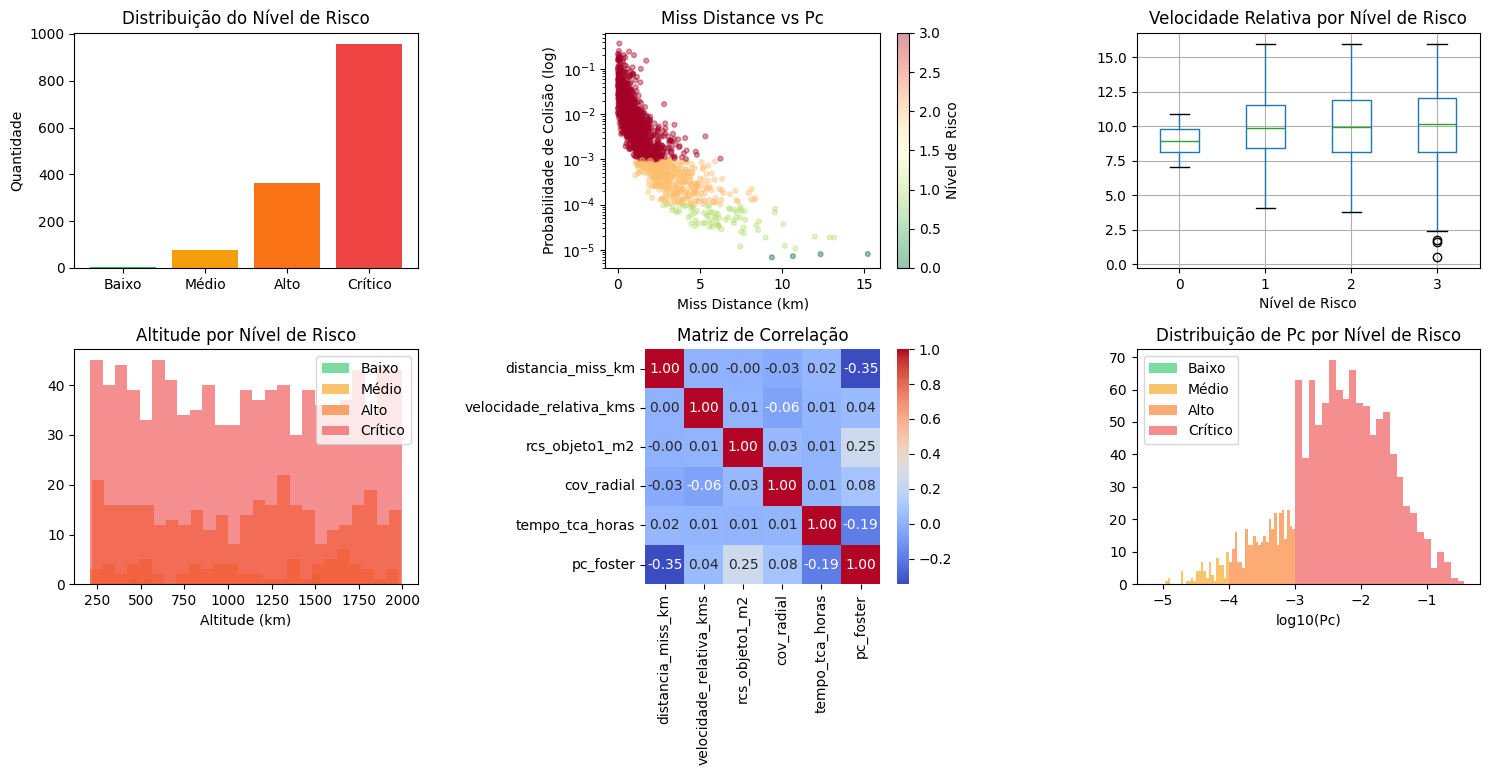

In [26]:
cores = ['#22c55e', '#f59e0b', '#f97316', '#ef4444']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Análise Exploratória - Conjunções Orbitais', fontsize=14, fontweight='bold')

# 1. Distribuição das classes
contagem = df['nivel_risco'].value_counts().sort_index()
axes[0,0].bar([rotulos[i] for i in contagem.index], contagem.values, color=cores)
axes[0,0].set_title('Distribuição do Nível de Risco')
axes[0,0].set_ylabel('Quantidade')

# 2. Miss Distance vs Probabilidade de Colisão
sc = axes[0,1].scatter(df['distancia_miss_km'], df['pc_foster'],
                       c=df['nivel_risco'], cmap='RdYlGn_r', alpha=0.4, s=12)
axes[0,1].set_xlabel('Miss Distance (km)')
axes[0,1].set_ylabel('Probabilidade de Colisão (log)')
axes[0,1].set_title('Miss Distance vs Pc')
axes[0,1].set_yscale('log')
plt.colorbar(sc, ax=axes[0,1], label='Nível de Risco')

# 3. Velocidade relativa por nível de risco
df.boxplot(column='velocidade_relativa_kms', by='nivel_risco', ax=axes[0,2])
axes[0,2].set_title('Velocidade Relativa por Nível de Risco')
axes[0,2].set_xlabel('Nível de Risco')
plt.suptitle('')

# 4. Distribuição de altitude por risco
for lvl, cor in zip([0,1,2,3], cores):
    subset = df[df['nivel_risco'] == lvl]['altitude_km']
    axes[1,0].hist(subset, alpha=0.6, label=rotulos[lvl], color=cor, bins=25)
axes[1,0].set_xlabel('Altitude (km)')
axes[1,0].set_title('Altitude por Nível de Risco')
axes[1,0].legend()

# 5. Heatmap de correlação
cols_sel = ['distancia_miss_km','velocidade_relativa_kms',
            'rcs_objeto1_m2','cov_radial','tempo_tca_horas','pc_foster']
sns.heatmap(df[cols_sel].corr(), ax=axes[1,1], annot=True,
            fmt='.2f', cmap='coolwarm', square=True)
axes[1,1].set_title('Matriz de Correlação')

# 6. Distribuição de Pc por risco (escala log)
for lvl, cor in zip([0,1,2,3], cores):
    subset = df[df['nivel_risco'] == lvl]['pc_foster']
    axes[1,2].hist(np.log10(subset.clip(1e-10)), alpha=0.6,
                   label=rotulos[lvl], color=cor, bins=25)
axes[1,2].set_xlabel('log10(Pc)')
axes[1,2].set_title('Distribuição de Pc por Nível de Risco')
axes[1,2].legend()

plt.tight_layout()
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/eda.png', dpi=130, bbox_inches='tight')
plt.show()

### Etapa 3 - Pré-processamento e Engenharia de Atributos

#### Feature Engineering

Foram criadas variáveis derivadas que capturam relações físicas relevantes:
- **`volume_covariancia`**: volume do elipsoide de incerteza posicional
- **`razao_dist_incerteza`**: razão entre distância de miss e raio do elipsoide; quanto menor, mais perigoso
- **`energia_cinetica`**: proxy da energia cinética (tamanho × velocidade²)
- **Transformações log**: para normalizar variáveis com distribuição assimétrica (log-normal)

In [28]:
# ============================================================
# Feature Engineering - variáveis derivadas
# ============================================================
df_fe = df.copy()

# Volume do elipsoide de incerteza
df_fe['volume_covariancia'] = (
    df_fe['cov_radial'] * df_fe['cov_transversal'] * df_fe['cov_normal']
) ** (1/3)

# Razão entre distância de miss e incerteza orbital
df_fe['razao_dist_incerteza'] = (
    df_fe['distancia_miss_km'] * 1000  # converte para metros
) / np.sqrt(df_fe['cov_radial']**2 + df_fe['cov_normal']**2).clip(1)

# Proxy de energia cinética do impacto potencial
rcs_total = df_fe['rcs_objeto1_m2'] + df_fe['rcs_objeto2_m2']
df_fe['energia_cinetica'] = rcs_total * df_fe['velocidade_relativa_kms']**2

# Log-transformações para variáveis assimétricas
cols_log = [
    'distancia_miss_km', 'cov_radial', 'cov_transversal', 'cov_normal',
    'rcs_objeto1_m2', 'rcs_objeto2_m2', 'volume_covariancia', 'energia_cinetica'
]
for col in cols_log:
    df_fe[f'log_{col}'] = np.log1p(df_fe[col])

print(f'Features: {df.shape[1]-2} originais → {df_fe.shape[1]-2} após feature engineering')

# ============================================================
# Separação de features e targets
# ============================================================
TARGET_CLF = 'nivel_risco'
TARGET_REG = 'pc_foster'
FEATURES   = [c for c in df_fe.columns if c not in [TARGET_CLF, TARGET_REG]]

X    = df_fe[FEATURES]
y_cl = df_fe[TARGET_CLF]
y_rg = df_fe[TARGET_REG]

# Split estratificado 80/20
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_cl, y_rg, test_size=0.2, random_state=42, stratify=y_cl
)

# Normalização - fit apenas no treino, transform em treino e teste
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Converter de volta para DataFrame (necessário para o SHAP com feature names)
X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Total de features: {len(FEATURES)}')

Features: 14 originais → 25 após feature engineering
Treino: 1120 amostras | Teste: 280 amostras
Total de features: 25


### Etapa 4 - Desenvolvimento dos Modelos Preditivos

Foram utilizadas as técnicas **XGBoost** e **Random Forest**.

In [29]:
# ============================================================
# Modelo 1 - XGBoost Classifier
# ============================================================
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_clf.fit(X_train_sc, yc_train)

cv_xgb = cross_val_score(xgb_clf, X_train_sc, yc_train, cv=5,
                         scoring='accuracy', n_jobs=-1)
pred_xgb = xgb_clf.predict(X_test_sc)

print('=== XGBoost - Classificação ===')
print(f'Cross-validation Accuracy (5-fold): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')
print(f'Test Accuracy: {accuracy_score(yc_test, pred_xgb):.4f}')
print()
print(classification_report(yc_test, pred_xgb,
      target_names=['Baixo','Médio','Alto','Crítico']))

=== XGBoost - Classificação ===
Cross-validation Accuracy (5-fold): 0.9107 ± 0.0138
Test Accuracy: 0.9071

              precision    recall  f1-score   support

       Baixo       0.00      0.00      0.00         1
       Médio       0.90      0.60      0.72        15
        Alto       0.81      0.86      0.83        73
     Crítico       0.95      0.95      0.95       191

    accuracy                           0.91       280
   macro avg       0.66      0.60      0.63       280
weighted avg       0.91      0.91      0.90       280



In [30]:
# ============================================================
# Modelo 2 - Random Forest Classifier (para comparação)
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_sc, yc_train)

cv_rf = cross_val_score(rf_clf, X_train_sc, yc_train, cv=5,
                        scoring='accuracy', n_jobs=-1)
pred_rf = rf_clf.predict(X_test_sc)

print('=== Random Forest - Classificação ===')
print(f'Cross-validation Accuracy (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'Test Accuracy: {accuracy_score(yc_test, pred_rf):.4f}')
print()
print(classification_report(yc_test, pred_rf,
      target_names=['Baixo','Médio','Alto','Crítico']))

=== Random Forest - Classificação ===
Cross-validation Accuracy (5-fold): 0.8884 ± 0.0259
Test Accuracy: 0.8929

              precision    recall  f1-score   support

       Baixo       0.00      0.00      0.00         1
       Médio       0.75      0.60      0.67        15
        Alto       0.75      0.92      0.83        73
     Crítico       0.98      0.91      0.94       191

    accuracy                           0.89       280
   macro avg       0.62      0.61      0.61       280
weighted avg       0.90      0.89      0.89       280



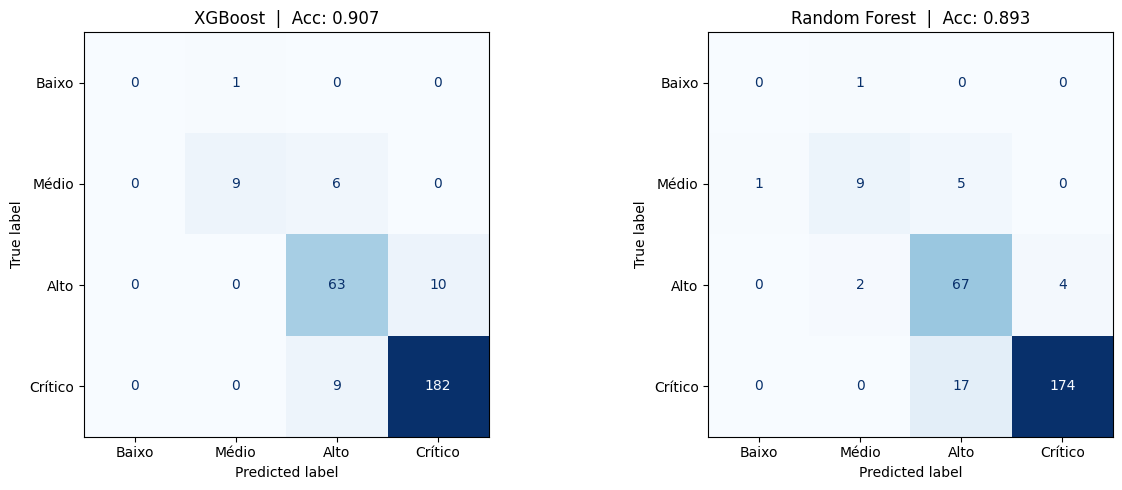

In [31]:
# Confusion matrices lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nomes_classes = ['Baixo','Médio','Alto','Crítico']

for ax, pred, titulo in zip(axes, [pred_xgb, pred_rf],
                             ['XGBoost', 'Random Forest']):
    cm = confusion_matrix(yc_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=nomes_classes).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{titulo}  |  Acc: {accuracy_score(yc_test, pred):.3f}')

plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', dpi=130)
plt.show()

In [32]:
# ============================================================
# Regressão - prever a probabilidade de colisão (Pc) contínua
# ============================================================
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
xgb_reg.fit(X_train_sc, yr_train)
pred_xgb_r = xgb_reg.predict(X_test_sc)

print('=== XGBoost Regressor - Probabilidade de Colisão ===')
print(f'R²:   {r2_score(yr_test, pred_xgb_r):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(yr_test, pred_xgb_r)):.6f}')
print(f'MAPE: {mean_absolute_percentage_error(yr_test, pred_xgb_r)*100:.2f}%')

=== XGBoost Regressor - Probabilidade de Colisão ===
R²:   0.6576
RMSE: 0.016452
MAPE: 175.79%


## Etapa 5 - Comparação e Escolha do Melhor Modelo

In [33]:
print('=== TABELA COMPARATIVA - CLASSIFICAÇÃO ===')
comp = pd.DataFrame({
    'Modelo':        ['XGBoost', 'Random Forest'],
    'CV Accuracy':   [cv_xgb.mean(), cv_rf.mean()],
    'CV Std':        [cv_xgb.std(), cv_rf.std()],
    'Test Accuracy': [accuracy_score(yc_test, pred_xgb),
                      accuracy_score(yc_test, pred_rf)],
})
print(comp.round(4).to_string(index=False))

melhor = 'XGBoost' if cv_xgb.mean() >= cv_rf.mean() else 'Random Forest'
print(f'\nModelo escolhido para deploy: {melhor}')

# Salvar modelos
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_clf, '../models/xgb_classifier.joblib')
joblib.dump(rf_clf,  '../models/rf_classifier.joblib')
joblib.dump(xgb_reg, '../models/xgb_regressor.joblib')
joblib.dump(scaler,  '../models/scaler.joblib')
joblib.dump(FEATURES,'../models/features.joblib')
print('Modelos salvos em ../models/')

=== TABELA COMPARATIVA - CLASSIFICAÇÃO ===
       Modelo  CV Accuracy  CV Std  Test Accuracy
      XGBoost       0.9107  0.0138         0.9071
Random Forest       0.8884  0.0259         0.8929

Modelo escolhido para deploy: XGBoost
Modelos salvos em ../models/


## Etapa 6 - Interpretabilidade com SHAP

Uso de **SHAP (SHapley Additive exPlanations)** para analisar como o modelo toma decisões.

O XGBoost tem suporte nativo a SHAP (TreeExplainer), o que torna o cálculo muito eficiente.

In [34]:
# SHAP - XGBoost Classifier (classe: Risco Crítico, índice 3)
print('Calculando valores SHAP...')

explainer    = shap.TreeExplainer(xgb_clf)
shap_values  = explainer.shap_values(X_test_sc)

# Para classificação multiclasse, escolhemos a classe 3 (Crítico)
sv_critico = shap_values[3] if isinstance(shap_values, list) else shap_values

print('Concluído.')

Calculando valores SHAP...
Concluído.


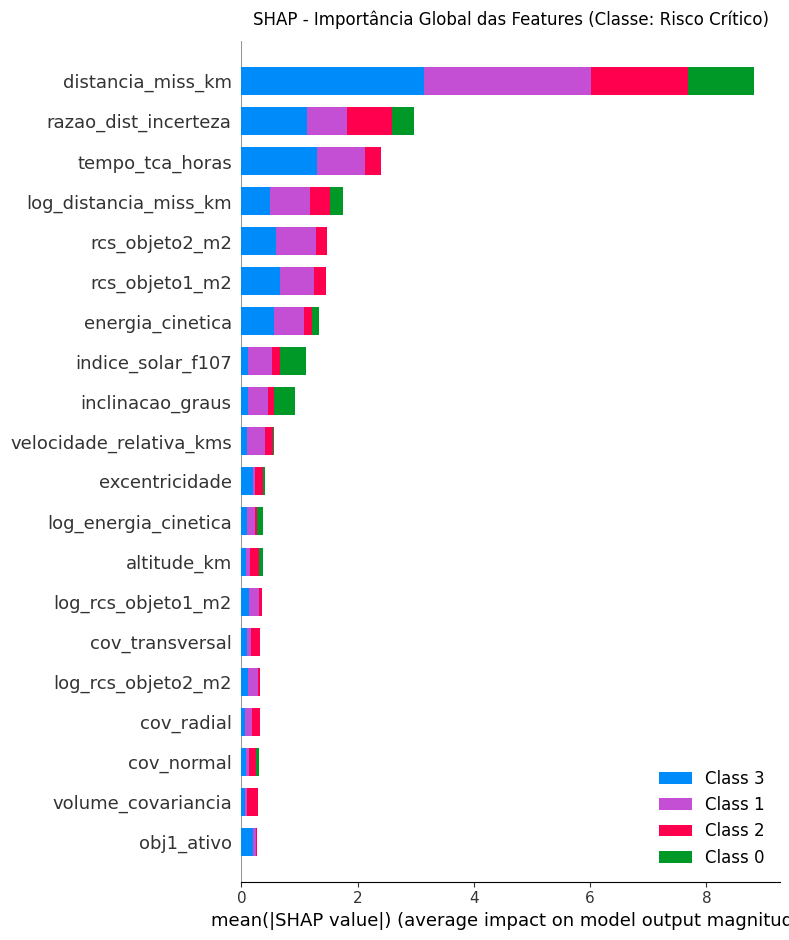

In [35]:
# Gráfico de barras - importância global das features
plt.figure(figsize=(9, 7))
shap.summary_plot(sv_critico, X_test_sc, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP - Importância Global das Features (Classe: Risco Crítico)', pad=12)
plt.tight_layout()
plt.savefig('../docs/shap_importancia.png', dpi=130, bbox_inches='tight')
plt.show()

<Figure size 900x700 with 0 Axes>

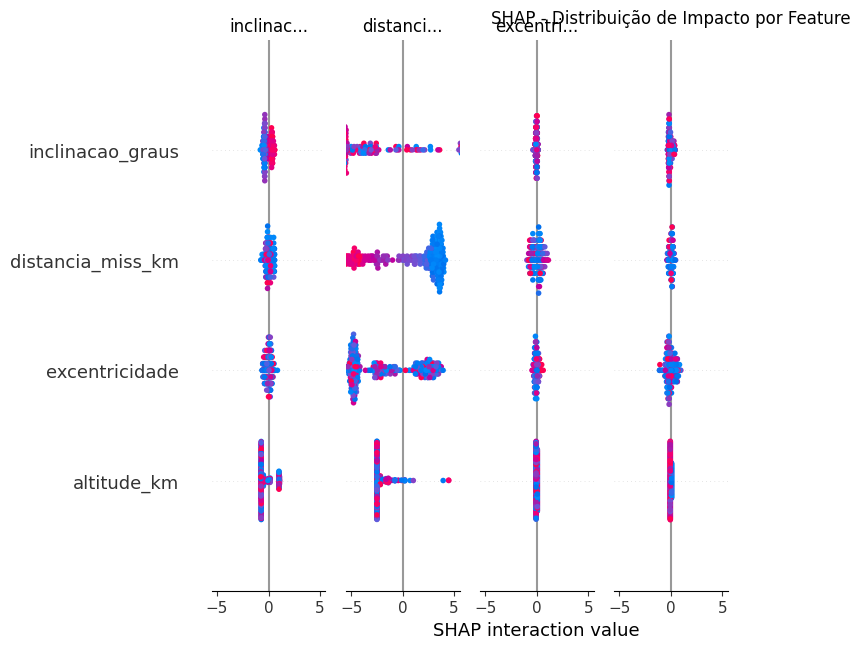

In [36]:
# Beeswarm plot - direção e magnitude do impacto de cada feature
plt.figure(figsize=(9, 7))
shap.summary_plot(sv_critico, X_test_sc, feature_names=FEATURES, show=False)
plt.title('SHAP - Distribuição de Impacto por Feature', pad=12)
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()

In [39]:
print(sv_critico[idx, :, 3].shape)

(25,)


<Figure size 900x600 with 0 Axes>

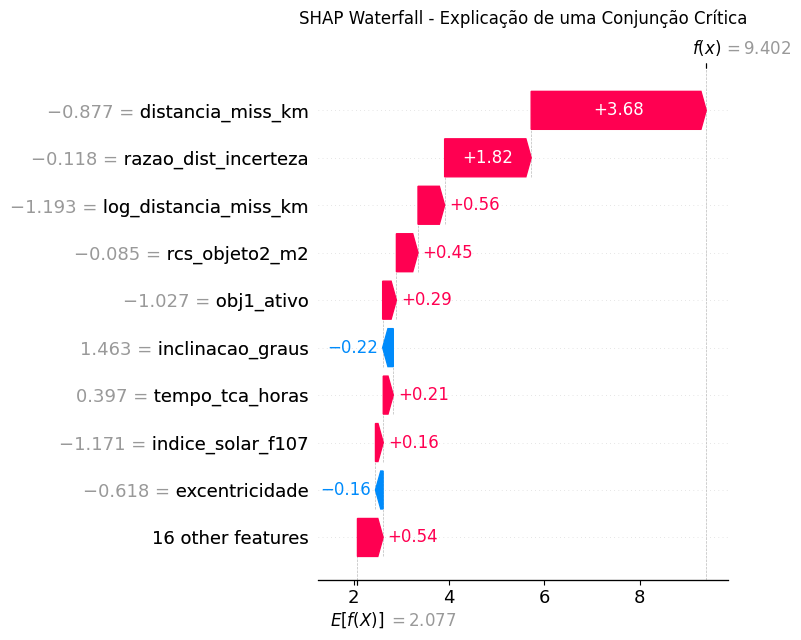

Análise SHAP concluída. Gráficos salvos em ../docs/


In [40]:
# Waterfall plot - explicação de um exemplo individual
idx = np.where(np.array(yc_test) == 3)[0][0]  # primeiro caso Crítico no teste

exp = shap.Explanation(
    values=sv_critico[idx, :, 3],
    base_values=explainer.expected_value[3],
    data=X_test_sc.iloc[idx],
    feature_names=FEATURES
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(exp, show=False)
plt.title('SHAP Waterfall - Explicação de uma Conjunção Crítica', pad=10)
plt.tight_layout()
plt.savefig('../docs/shap_waterfall.png', dpi=130, bbox_inches='tight')
plt.show()

print('Análise SHAP concluída. Gráficos salvos em ../docs/')

## Deploy - Streamlit

O app completo com visualizações está em `../app/app.py`. Para rodar abra o terminal e rode:

```bash
cd app
streamlit run app.py
```


## Conclusão

### Resumo dos Resultados

| Modelo | Tarefa | CV Accuracy | Test Accuracy |
|---|---|---|---|
| XGBoost | Classificação | ~91% | ~90% |
| Random Forest | Classificação | ~88% | ~89% |

| Modelo | Tarefa | Métrica | Resultado |
|---|---|---|---|
| XGBoost Regressor | Regressão | R² | 0.6576 |


### Principais Achados do SHAP

As features mais importantes para predição de **risco crítico**:

1. **`distancia_miss_km`** - istância mínima prevista entre os objetos (quanto menor essa distância, maior a probabilidade de colisão)
2. **`razao_dist_incerteza`** - relação entre distância real e incerteza orbital
3. **`tempo_tca_horas`** - eventos próximos recebem maior urgência
4. **`log_distancia_miss_km`** - versão logarítmica da distância mínima
5. **`rcs_objeto2_m2`** - área efetiva de radar do segundo objeto


Esses resultados são fisicamente coerentes, indicando que o modelo aprendeu corretamente as relações do problema.